# Mount drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Imports & Paths

In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")


PROJECT_DIR = Path(
    "/content/drive/MyDrive/Colab Notebooks/Dissertation"
)

RUNS_DIR = PROJECT_DIR / "Runs"
RESULTS_DIR = PROJECT_DIR / "Results"

OUTPUT_DIR = RESULTS_DIR / "in_domain_analysis"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR = OUTPUT_DIR / "figures"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

assert RUNS_DIR.exists(), f"Runs directory not found: {RUNS_DIR}"

print("Project directory:", PROJECT_DIR)
print("Runs directory:", RUNS_DIR)
print("Output directory:", OUTPUT_DIR)

Project directory: /content/drive/MyDrive/Colab Notebooks/Dissertation
Runs directory: /content/drive/MyDrive/Colab Notebooks/Dissertation/Runs
Output directory: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/in_domain_analysis


# Summary results files

In [9]:
def load_all_result_summaries(runs_directory):
    """
    Load all compatible experiment summary CSV files.

    The function also converts the old YOLO DAWN
    weather_results_summary.csv format automatically.
    """

    summary_files = sorted(
        file_path
        for file_path in runs_directory.rglob("*.csv")
        if "summary" in file_path.name.lower()
    )

    loaded_frames = []
    ignored_files = []

    required_columns = {
        "model",
        "experiment",
        "seed",
        "condition",
        "mAP50-95",
        "mAP50",
    }

    for file_path in summary_files:

        try:
            current_df = pd.read_csv(file_path)


            # Old YOLO DAWN summary format
            is_old_yolo_dawn_format = (
                file_path.name == "weather_results_summary.csv"
                and list(current_df.columns)
                == ["global", "fog", "rain", "snow"]
                and len(current_df) == 4
            )

            if is_old_yolo_dawn_format:

                current_df.index = [
                    "mAP50",
                    "mAP50-95",
                    "Precision",
                    "Recall",
                ]

                current_df = (
                    current_df
                    .T
                    .reset_index()
                    .rename(columns={"index": "condition"})
                )

                current_df.insert(0, "seed", 42)
                current_df.insert(0, "experiment", "in_domain")
                current_df.insert(0, "model", "YOLOv11s")
                current_df.insert(0, "dataset", "DAWN")

                precision = current_df["Precision"]
                recall = current_df["Recall"]

                current_df["F1-score"] = np.where(
                    precision + recall > 0,
                    2 * precision * recall / (precision + recall),
                    np.nan,
                )

            # Normal summary files
            elif not required_columns.issubset(current_df.columns):

                missing_columns = sorted(
                    required_columns - set(current_df.columns)
                )

                ignored_files.append(
                    {
                        "file": str(
                            file_path.relative_to(runs_directory)
                        ),
                        "reason": (
                            f"Missing columns: {missing_columns}"
                        ),
                    }
                )

                continue

            current_df["source_file"] = str(
                file_path.relative_to(runs_directory)
            )

            loaded_frames.append(current_df)

        except Exception as error:

            ignored_files.append(
                {
                    "file": str(
                        file_path.relative_to(runs_directory)
                    ),
                    "reason": str(error),
                }
            )

    if not loaded_frames:
        raise RuntimeError(
            "No compatible result summary file was found."
        )

    results_df = pd.concat(
        loaded_frames,
        ignore_index=True,
        sort=False,
    )

    ignored_df = pd.DataFrame(ignored_files)

    print("Summary files found:", len(summary_files))
    print("Loaded files:", len(loaded_frames))
    print("Loaded rows:", len(results_df))
    print("Ignored files:", len(ignored_files))

    return results_df, ignored_df

## Load results

In [10]:
raw_results_df, ignored_files_df = (
    load_all_result_summaries(RUNS_DIR)
)

display(raw_results_df.head())

Summary files found: 13
Loaded files: 13
Loaded rows: 52
Ignored files: 0


,dataset,model,experiment,seed,condition,mAP50-95,mAP50,mAP75,Inference_ms_per_image,FPS,source_file,source_train_dataset,target_test_dataset,Precision,Recall,F1-score
0,ACDC,Faster R-CNN,in_domain,123,global,0.4283,0.6121,0.4556,61.7702,16.1890,faster_rcnn/acdc_in_domain_faster_rcnn_seed123...,NaN,NaN,NaN,NaN,NaN
1,ACDC,Faster R-CNN,in_domain,123,fog,0.5722,0.7643,0.6215,61.7869,16.1847,faster_rcnn/acdc_in_domain_faster_rcnn_seed123...,NaN,NaN,NaN,NaN,NaN
2,ACDC,Faster R-CNN,in_domain,123,rain,0.3745,0.5446,0.3881,60.9978,16.3940,faster_rcnn/acdc_in_domain_faster_rcnn_seed123...,NaN,NaN,NaN,NaN,NaN
3,ACDC,Faster R-CNN,in_domain,123,snow,0.5154,0.6973,0.5677,61.9047,16.1539,faster_rcnn/acdc_in_domain_faster_rcnn_seed123...,NaN,NaN,NaN,NaN,NaN
4,ACDC,Faster R-CNN,in_domain,42,global,0.4128,0.5963,0.4499,62.1002,16.1030,faster_rcnn/acdc_in_domain_faster_rcnn_seed42/...,NaN,NaN,NaN,NaN,NaN


In [11]:
if ignored_files_df.empty:
    print("No result summary file was ignored.")
else:
    display(ignored_files_df)

No result summary file was ignored.


### Uniform data

In [12]:
def standardise_results(dataframe):
    """
    Standardise column values and data types.
    """

    dataframe = dataframe.copy()

    dataframe.columns = [
        column.strip()
        for column in dataframe.columns
    ]

    # Standardise text columns
    text_columns = [
        "dataset",
        "source_train_dataset",
        "target_test_dataset",
        "model",
        "experiment",
        "condition",
    ]

    for column in text_columns:
        if column in dataframe.columns:
            dataframe[column] = (
                dataframe[column]
                .astype("string")
                .str.strip()
            )

    # Model names
    model_mapping = {
        "YOLO": "YOLOv11s",
        "YOLO11s": "YOLOv11s",
        "YOLOv11s": "YOLOv11s",
        "FasterRCNN": "Faster R-CNN",
        "Faster RCNN": "Faster R-CNN",
        "Faster R-CNN": "Faster R-CNN",
    }

    dataframe["model"] = dataframe["model"].replace(
        model_mapping
    )

    # Experiment names
    dataframe["experiment"] = (
        dataframe["experiment"]
        .str.lower()
        .str.replace("-", "_", regex=False)
        .str.replace(" ", "_", regex=False)
    )

    # Conditions
    dataframe["condition"] = (
        dataframe["condition"]
        .str.lower()
    )

    # Dataset names
    if "dataset" not in dataframe.columns:
        dataframe["dataset"] = pd.NA

    if "source_train_dataset" in dataframe.columns:
        dataframe["dataset"] = dataframe["dataset"].fillna(
            dataframe["source_train_dataset"]
        )

    dataframe["dataset"] = (
        dataframe["dataset"]
        .str.upper()
    )

    # Numeric columns
    numeric_columns = [
        "seed",
        "mAP50-95",
        "mAP50",
        "mAP75",
        "Precision",
        "Recall",
        "F1-score",
        "Preprocess_ms_per_image",
        "Inference_ms_per_image",
        "Postprocess_ms_per_image",
        "Total_ms_per_image",
        "FPS",
    ]

    for column in numeric_columns:
        if column in dataframe.columns:
            dataframe[column] = pd.to_numeric(
                dataframe[column],
                errors="coerce",
            )

    return dataframe

### Apply cleaning

In [13]:
results_df = standardise_results(raw_results_df)

print("Models:")
print(results_df["model"].value_counts(dropna=False))

print("\nExperiments:")
print(results_df["experiment"].value_counts(dropna=False))

print("\nSeeds:")
print(sorted(results_df["seed"].dropna().unique()))

print("\nConditions:")
print(results_df["condition"].value_counts(dropna=False))

Models:
model
Faster R-CNN    44
YOLOv11s         8
Name: count, dtype: Int64

Experiments:
experiment
in_domain     28
acdc_>dawn    12
dawn_>acdc    12
Name: count, dtype: Int64

Seeds:
[np.int64(42), np.int64(123), np.int64(456)]

Conditions:
condition
global    13
fog       13
rain      13
snow      13
Name: count, dtype: Int64


## **Select in domain seed 42**

In [14]:
in_domain_df = results_df[
    results_df["experiment"].str.contains(
        r"in[_-]?domain",
        case=False,
        na=False,
        regex=True,
    )
    & (results_df["seed"] == 42)
].copy()

in_domain_df = (
    in_domain_df
    .sort_values(
        ["dataset", "model", "condition"]
    )
    .reset_index(drop=True)
)

print("In-domain seed 42 rows:", len(in_domain_df))

display(
    in_domain_df[
        [
            column
            for column in [
                "dataset",
                "model",
                "seed",
                "condition",
                "mAP50-95",
                "mAP50",
                "mAP75",
                "Precision",
                "Recall",
                "F1-score",
                "Inference_ms_per_image",
                "FPS",
            ]
            if column in in_domain_df.columns
        ]
    ]
)

In-domain seed 42 rows: 16


,dataset,model,seed,condition,mAP50-95,mAP50,mAP75,Precision,Recall,F1-score,Inference_ms_per_image,FPS
0,ACDC,Faster R-CNN,42,fog,0.5472,0.7540,0.5907,NaN,NaN,NaN,61.8578,16.1661
1,ACDC,Faster R-CNN,42,global,0.4128,0.5963,0.4499,NaN,NaN,NaN,62.1002,16.1030
2,ACDC,Faster R-CNN,42,rain,0.3631,0.5262,0.3973,NaN,NaN,NaN,61.8912,16.1574
3,ACDC,Faster R-CNN,42,snow,0.4889,0.6951,0.5272,NaN,NaN,NaN,61.8987,16.1554
4,ACDC,YOLOv11s,42,fog,0.4127,0.6277,0.4272,0.8584,0.5470,0.6682,11.7454,85.1397
5,ACDC,YOLOv11s,42,global,0.3329,0.5212,0.3455,0.7650,0.4413,0.5597,11.8298,84.5323
6,ACDC,YOLOv11s,42,rain,0.3081,0.4836,0.3194,0.7661,0.4058,0.5306,11.6544,85.8047
7,ACDC,YOLOv11s,42,snow,0.3560,0.5598,0.3648,0.7243,0.4606,0.5631,11.9452,83.7153
8,DAWN,Faster R-CNN,42,fog,0.4153,0.5998,0.4766,NaN,NaN,NaN,48.6164,20.5692
9,DAWN,Faster R-CNN,42,global,0.4679,0.7095,0.5521,NaN,NaN,NaN,48.6836,20.5414


In [27]:
# Cellule 8 bis — Fill YOLO DAWN global speed values

row_mask = (
    (in_domain_df["dataset"] == "DAWN")
    & (in_domain_df["model"] == "YOLOv11s")
    & (in_domain_df["seed"] == 42)
    & (in_domain_df["condition"] == "global")
)

in_domain_df.loc[
    row_mask,
    "FPS",
] = 80.30

in_domain_df.loc[
    row_mask,
    "Inference_ms_per_image",
] = 1000 / 80.30

display(
    in_domain_df.loc[
        row_mask,
        [
            "dataset",
            "model",
            "condition",
            "mAP50-95",
            "Inference_ms_per_image",
            "FPS",
        ],
    ]
)

,dataset,model,condition,mAP50-95,Inference_ms_per_image,FPS
13,DAWN,YOLOv11s,global,0.3396,12.4533,80.3000


### Check coverage

In [28]:
coverage_table = (
    in_domain_df
    .groupby(["dataset", "model"])
    .agg(
        number_of_conditions=("condition", "nunique"),
        conditions=(
            "condition",
            lambda values: ", ".join(
                sorted(values.dropna().unique())
            ),
        ),
    )
    .reset_index()
)

display(coverage_table)

,dataset,model,number_of_conditions,conditions
0,ACDC,Faster R-CNN,4,"fog, global, rain, snow"
1,ACDC,YOLOv11s,4,"fog, global, rain, snow"
2,DAWN,Faster R-CNN,4,"fog, global, rain, snow"
3,DAWN,YOLOv11s,4,"fog, global, rain, snow"


### Check duplication

In [29]:
duplicate_key = [
    "dataset",
    "model",
    "seed",
    "condition",
]

duplicate_rows = in_domain_df[
    in_domain_df.duplicated(
        subset=duplicate_key,
        keep=False,
    )
]

if duplicate_rows.empty:
    print("No duplicated in-domain result was found.")
else:
    print("Warning: duplicated results were found.")

    display(
        duplicate_rows[
            duplicate_key
            + [
                "mAP50-95",
                "source_file",
            ]
        ]
    )

No duplicated in-domain result was found.


## Create Global table

In [30]:
global_in_domain_df = in_domain_df[
    in_domain_df["condition"] == "global"
].copy()

global_columns = [
    "dataset",
    "model",
    "seed",
    "mAP50-95",
    "mAP50",
    "mAP75",
    "Precision",
    "Recall",
    "F1-score",
    "Inference_ms_per_image",
    "FPS",
]

global_columns = [
    column
    for column in global_columns
    if column in global_in_domain_df.columns
]

global_results_table = (
    global_in_domain_df[global_columns]
    .sort_values(["dataset", "model"])
    .reset_index(drop=True)
)

display(global_results_table)

,dataset,model,seed,mAP50-95,mAP50,mAP75,Precision,Recall,F1-score,Inference_ms_per_image,FPS
0,ACDC,Faster R-CNN,42,0.4128,0.5963,0.4499,NaN,NaN,NaN,62.1002,16.1030
1,ACDC,YOLOv11s,42,0.3329,0.5212,0.3455,0.7650,0.4413,0.5597,11.8298,84.5323
2,DAWN,Faster R-CNN,42,0.4679,0.7095,0.5521,NaN,NaN,NaN,48.6836,20.5414
3,DAWN,YOLOv11s,42,0.3396,0.5812,NaN,0.5776,0.5928,0.5851,12.4533,80.3000


### Publication table

In [31]:
publication_table = global_results_table.copy()

publication_table = publication_table.rename(
    columns={
        "dataset": "Dataset",
        "model": "Model",
        "seed": "Seed",
        "mAP50-95": "mAP@0.50:0.95",
        "mAP50": "mAP@0.50",
        "mAP75": "mAP@0.75",
        "Precision": "Precision",
        "Recall": "Recall",
        "F1-score": "F1-score",
        "Inference_ms_per_image": "Inference (ms/image)",
        "FPS": "FPS",
    }
)

numeric_publication_columns = (
    publication_table
    .select_dtypes(include="number")
    .columns
)

publication_table[
    numeric_publication_columns
] = publication_table[
    numeric_publication_columns
].round(4)

display(publication_table)

,Dataset,Model,Seed,mAP@0.50:0.95,mAP@0.50,mAP@0.75,Precision,Recall,F1-score,Inference (ms/image),FPS
0,ACDC,Faster R-CNN,42,0.4128,0.5963,0.4499,NaN,NaN,NaN,62.1002,16.1030
1,ACDC,YOLOv11s,42,0.3329,0.5212,0.3455,0.7650,0.4413,0.5597,11.8298,84.5323
2,DAWN,Faster R-CNN,42,0.4679,0.7095,0.5521,NaN,NaN,NaN,48.6836,20.5414
3,DAWN,YOLOv11s,42,0.3396,0.5812,NaN,0.5776,0.5928,0.5851,12.4533,80.3000


## Save tables

In [32]:
raw_table_path = (
    TABLES_DIR
    / "in_domain_global_results_raw.csv"
)

publication_table_path = (
    TABLES_DIR
    / "in_domain_global_results_publication.csv"
)

weather_table_path = (
    TABLES_DIR
    / "in_domain_weather_results.csv"
)

global_results_table.to_csv(
    raw_table_path,
    index=False,
)

publication_table.to_csv(
    publication_table_path,
    index=False,
)

in_domain_df.to_csv(
    weather_table_path,
    index=False,
)

print("Saved:", raw_table_path)
print("Saved:", publication_table_path)
print("Saved:", weather_table_path)

Saved: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/in_domain_analysis/tables/in_domain_global_results_raw.csv
Saved: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/in_domain_analysis/tables/in_domain_global_results_publication.csv
Saved: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/in_domain_analysis/tables/in_domain_weather_results.csv


# Graphs

In [33]:
def plot_grouped_metric(
    dataframe,
    metric,
    ylabel,
    title,
    output_filename,
    decimals=3,
):
    """
    Create and save a grouped bar chart.
    """

    if metric not in dataframe.columns:
        print(f"{metric} is not available.")
        return

    valid_df = dataframe.dropna(
        subset=["dataset", "model", metric]
    )

    if valid_df.empty:
        print(f"No valid values are available for {metric}.")
        return

    plot_df = valid_df.pivot(
        index="dataset",
        columns="model",
        values=metric,
    )

    preferred_order = [
        "YOLOv11s",
        "Faster R-CNN",
    ]

    available_models = [
        model
        for model in preferred_order
        if model in plot_df.columns
    ]

    plot_df = plot_df.reindex(
        columns=available_models
    )

    axis = plot_df.plot(
        kind="bar",
        figsize=(8, 5),
        width=0.75,
    )

    axis.set_title(title)
    axis.set_xlabel("Dataset")
    axis.set_ylabel(ylabel)
    axis.tick_params(axis="x", rotation=0)

    axis.legend(
        title="Model",
        frameon=False,
    )

    axis.grid(
        axis="y",
        linestyle="--",
        alpha=0.4,
    )

    for container_item in axis.containers:
        axis.bar_label(
            container_item,
            fmt=f"%.{decimals}f",
            padding=3,
            fontsize=9,
        )

    plt.tight_layout()

    output_path = FIGURES_DIR / output_filename

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print("Saved:", output_path)

## Graph mAP@0.50:0.95

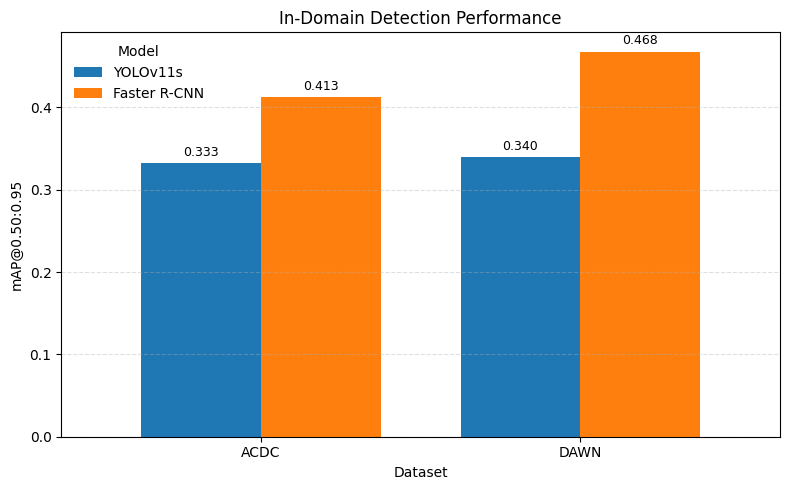

Saved: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/in_domain_analysis/figures/in_domain_map50_95.png


In [34]:
plot_grouped_metric(
    dataframe=global_in_domain_df,
    metric="mAP50-95",
    ylabel="mAP@0.50:0.95",
    title="In-Domain Detection Performance",
    output_filename="in_domain_map50_95.png",
)

## Graph mAP@0.50

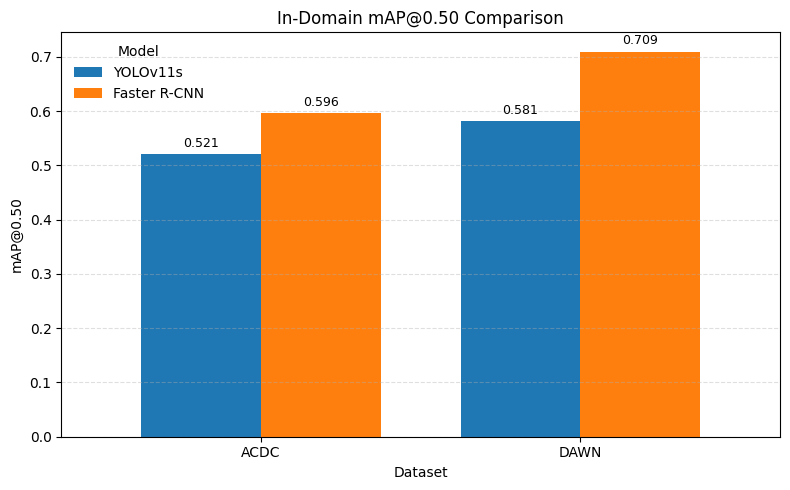

Saved: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/in_domain_analysis/figures/in_domain_map50.png


In [22]:
plot_grouped_metric(
    dataframe=global_in_domain_df,
    metric="mAP50",
    ylabel="mAP@0.50",
    title="In-Domain mAP@0.50 Comparison",
    output_filename="in_domain_map50.png",
)

## Graph mAP@0.75

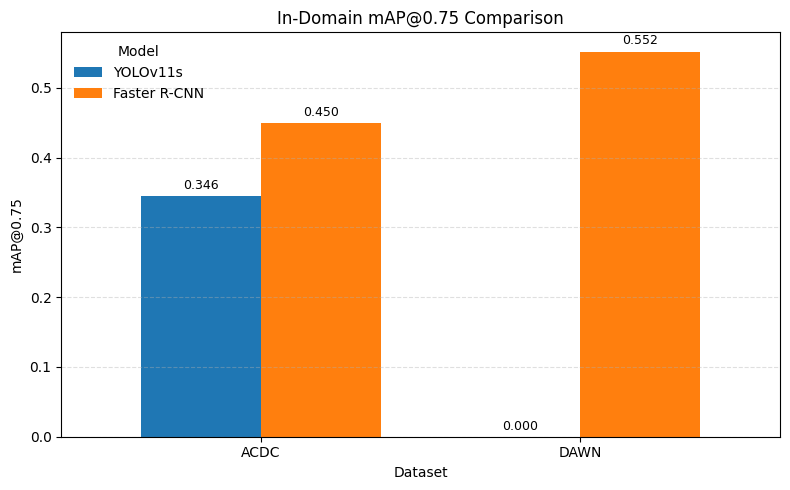

Saved: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/in_domain_analysis/figures/in_domain_map75.png


In [35]:
plot_grouped_metric(
    dataframe=global_in_domain_df,
    metric="mAP75",
    ylabel="mAP@0.75",
    title="In-Domain mAP@0.75 Comparison",
    output_filename="in_domain_map75.png",
)

## Graph FPS

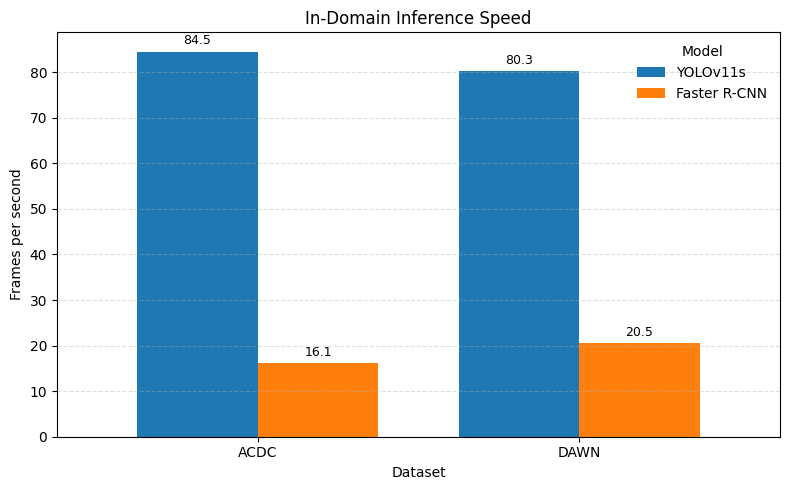

Saved: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/in_domain_analysis/figures/in_domain_fps.png


In [36]:
plot_grouped_metric(
    dataframe=global_in_domain_df,
    metric="FPS",
    ylabel="Frames per second",
    title="In-Domain Inference Speed",
    output_filename="in_domain_fps.png",
    decimals=1,
)

## Inference time Graph

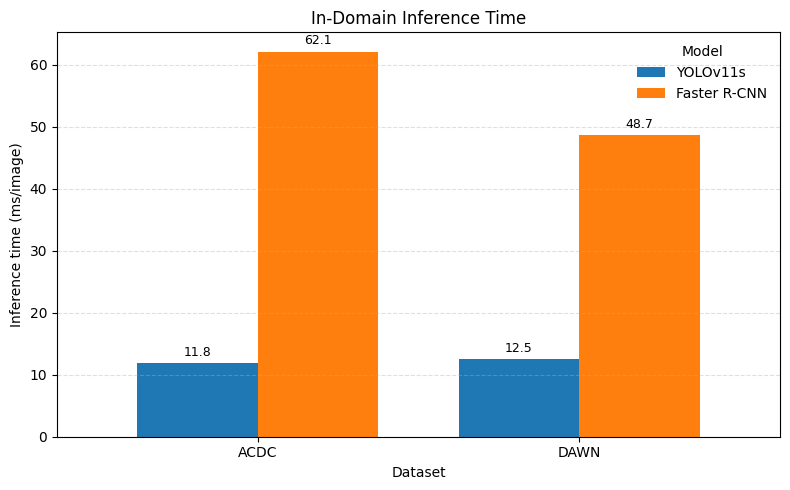

Saved: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/in_domain_analysis/figures/in_domain_inference_time.png


In [37]:
plot_grouped_metric(
    dataframe=global_in_domain_df,
    metric="Inference_ms_per_image",
    ylabel="Inference time (ms/image)",
    title="In-Domain Inference Time",
    output_filename="in_domain_inference_time.png",
    decimals=1,
)

## Accuracy–speed trade-off

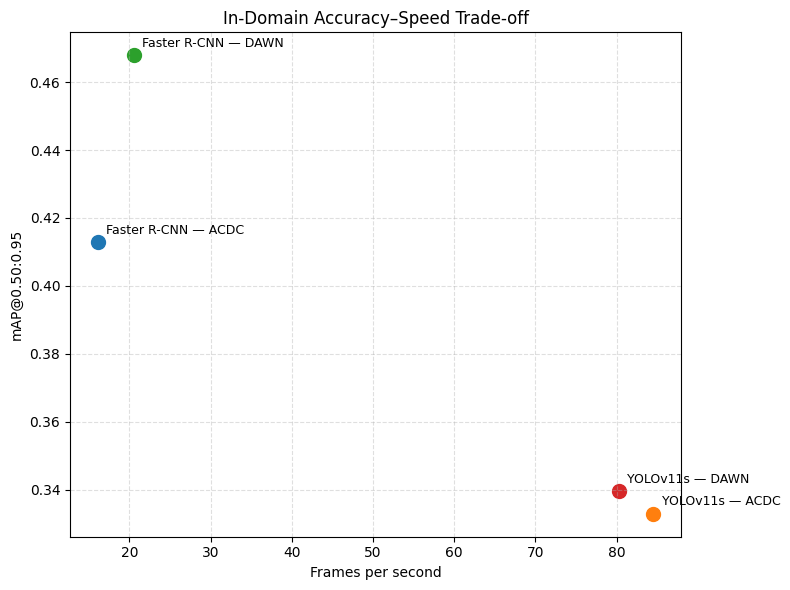

Saved: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/in_domain_analysis/figures/in_domain_accuracy_speed_tradeoff.png


In [38]:
required_speed_columns = {
    "dataset",
    "model",
    "mAP50-95",
    "FPS",
}

if required_speed_columns.issubset(
    global_in_domain_df.columns
):

    accuracy_speed_df = global_in_domain_df[
        [
            "dataset",
            "model",
            "mAP50-95",
            "FPS",
        ]
    ].dropna()

    if len(accuracy_speed_df) >= 2:

        plt.figure(figsize=(8, 6))

        for _, row in accuracy_speed_df.iterrows():

            plt.scatter(
                row["FPS"],
                row["mAP50-95"],
                s=100,
            )

            plt.annotate(
                f'{row["model"]} — {row["dataset"]}',
                (
                    row["FPS"],
                    row["mAP50-95"],
                ),
                xytext=(6, 6),
                textcoords="offset points",
                fontsize=9,
            )

        plt.xlabel("Frames per second")
        plt.ylabel("mAP@0.50:0.95")
        plt.title("In-Domain Accuracy–Speed Trade-off")

        plt.grid(
            linestyle="--",
            alpha=0.4,
        )

        plt.tight_layout()

        tradeoff_path = (
            FIGURES_DIR
            / "in_domain_accuracy_speed_tradeoff.png"
        )

        plt.savefig(
            tradeoff_path,
            dpi=300,
            bbox_inches="tight",
        )

        plt.show()

        print("Saved:", tradeoff_path)

    else:
        print(
            "Not enough complete accuracy and speed "
            "values for the trade-off plot."
        )
else:
    print("Accuracy or speed columns are unavailable.")

# YOLO VS Faster R-CNN

In [39]:
comparison_rows = []

for dataset in sorted(
    global_in_domain_df["dataset"].dropna().unique()
):

    dataset_df = global_in_domain_df[
        global_in_domain_df["dataset"] == dataset
    ].set_index("model")

    if not {
        "YOLOv11s",
        "Faster R-CNN",
    }.issubset(dataset_df.index):
        continue

    yolo_map = dataset_df.loc[
        "YOLOv11s",
        "mAP50-95",
    ]

    faster_map = dataset_df.loc[
        "Faster R-CNN",
        "mAP50-95",
    ]

    comparison_rows.append(
        {
            "Dataset": dataset,
            "YOLOv11s mAP@0.50:0.95": yolo_map,
            "Faster R-CNN mAP@0.50:0.95": faster_map,
            "Absolute difference": faster_map - yolo_map,
            "Relative improvement (%)": (
                (faster_map - yolo_map)
                / yolo_map
                * 100
            ),
        }
    )

accuracy_comparison_table = pd.DataFrame(
    comparison_rows
)

display(accuracy_comparison_table.round(4))

,Dataset,YOLOv11s mAP@0.50:0.95,Faster R-CNN mAP@0.50:0.95,Absolute difference,Relative improvement (%)
0,ACDC,0.3329,0.4128,0.0799,23.9917
1,DAWN,0.3396,0.4679,0.1283,37.7647


# Interpretation

In [40]:
interpretation_lines = []

for _, row in accuracy_comparison_table.iterrows():

    interpretation_lines.append(
        (
            f'On {row["Dataset"]}, Faster R-CNN achieved '
            f'an mAP@0.50:0.95 of '
            f'{row["Faster R-CNN mAP@0.50:0.95"]:.3f}, '
            f'compared with '
            f'{row["YOLOv11s mAP@0.50:0.95"]:.3f} '
            f'for YOLOv11s. This represents an absolute '
            f'improvement of '
            f'{row["Absolute difference"]:.3f}.'
        )
    )

interpretation_text = "\n\n".join(
    interpretation_lines
)

print(interpretation_text)

On ACDC, Faster R-CNN achieved an mAP@0.50:0.95 of 0.413, compared with 0.333 for YOLOv11s. This represents an absolute improvement of 0.080.

On DAWN, Faster R-CNN achieved an mAP@0.50:0.95 of 0.468, compared with 0.340 for YOLOv11s. This represents an absolute improvement of 0.128.


### Save interpretation

In [41]:
interpretation_path = (
    OUTPUT_DIR
    / "in_domain_interpretation.txt"
)

interpretation_path.write_text(
    interpretation_text,
    encoding="utf-8",
)

print("Saved:", interpretation_path)

Saved: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/in_domain_analysis/in_domain_interpretation.txt


# Generated files

In [42]:
generated_files = sorted(
    file_path
    for file_path in OUTPUT_DIR.rglob("*")
    if file_path.is_file()
)

print(f"Generated files: {len(generated_files)}\n")

for file_path in generated_files:
    print(file_path.relative_to(OUTPUT_DIR))

Generated files: 10

figures/in_domain_accuracy_speed_tradeoff.png
figures/in_domain_fps.png
figures/in_domain_inference_time.png
figures/in_domain_map50.png
figures/in_domain_map50_95.png
figures/in_domain_map75.png
in_domain_interpretation.txt
tables/in_domain_global_results_publication.csv
tables/in_domain_global_results_raw.csv
tables/in_domain_weather_results.csv
